In [31]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

# ---------------- مسارات الداتا ----------------
images_path = "BCCD/JPEGImages"
annotations_path = "BCCD/Annotations"

all_images = sorted([f for f in os.listdir(images_path) if f.endswith(".jpg")])
test_images = all_images[:30]  # هنجرب على 30 صورة كعينة


def get_actual_counts(img_name):
    """قراءة العدد الحقيقي للـ RBCs والـ WBCs من ملف الـ XML"""
    xml_name = img_name.replace(".jpg", ".xml")
    xml_file = os.path.join(annotations_path, xml_name)

    counts = {"RBC": 0, "WBC": 0}

    if not os.path.exists(xml_file):
        return counts

    tree = ET.parse(xml_file)
    root = tree.getroot()

    for obj in root.findall("object"):
        label = obj.find("name").text
        if label in counts:
            counts[label] += 1

    return counts

In [32]:
# ==========================================
# 2. دوال استخراج كرات الدم البيضاء (WBCs)
# ==========================================
def get_wbc_mask(img):
    """عزل النواة البنفسجية باستخدام مساحة ألوان HSV"""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_purple = np.array([115, 50, 80])
    upper_purple = np.array([160, 255, 255])
    binary_mask = cv2.inRange(hsv, lower_purple, upper_purple)
    return binary_mask


def clean_wbc_noise(binary_mask):
    """تنظيف الماسك من النغمشة"""
    kernel = np.ones((5, 5), np.uint8)
    mask_closed = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    cleaned_mask = cv2.medianBlur(mask_closed, 7)
    return cleaned_mask


def extract_wbc_contours(cleaned_mask, min_wbc_area=1000):
    """استخراج الكنتورز والتأكد من الحجم"""
    contours, _ = cv2.findContours(
        cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    wbc_contours = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > min_wbc_area:
            wbc_contours.append(cnt)
    return wbc_contours


def draw_wbcs(img_rgb, wbc_contours):
    """رسم مربعات حول الخلايا البيضاء"""
    img_out = img_rgb.copy()
    for cnt in wbc_contours:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_out, (x, y), (x + w, y + h), (255, 0, 0), 3)  # لون أحمر
        cv2.putText(
            img_out, "WBC", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2
        )
    return img_out

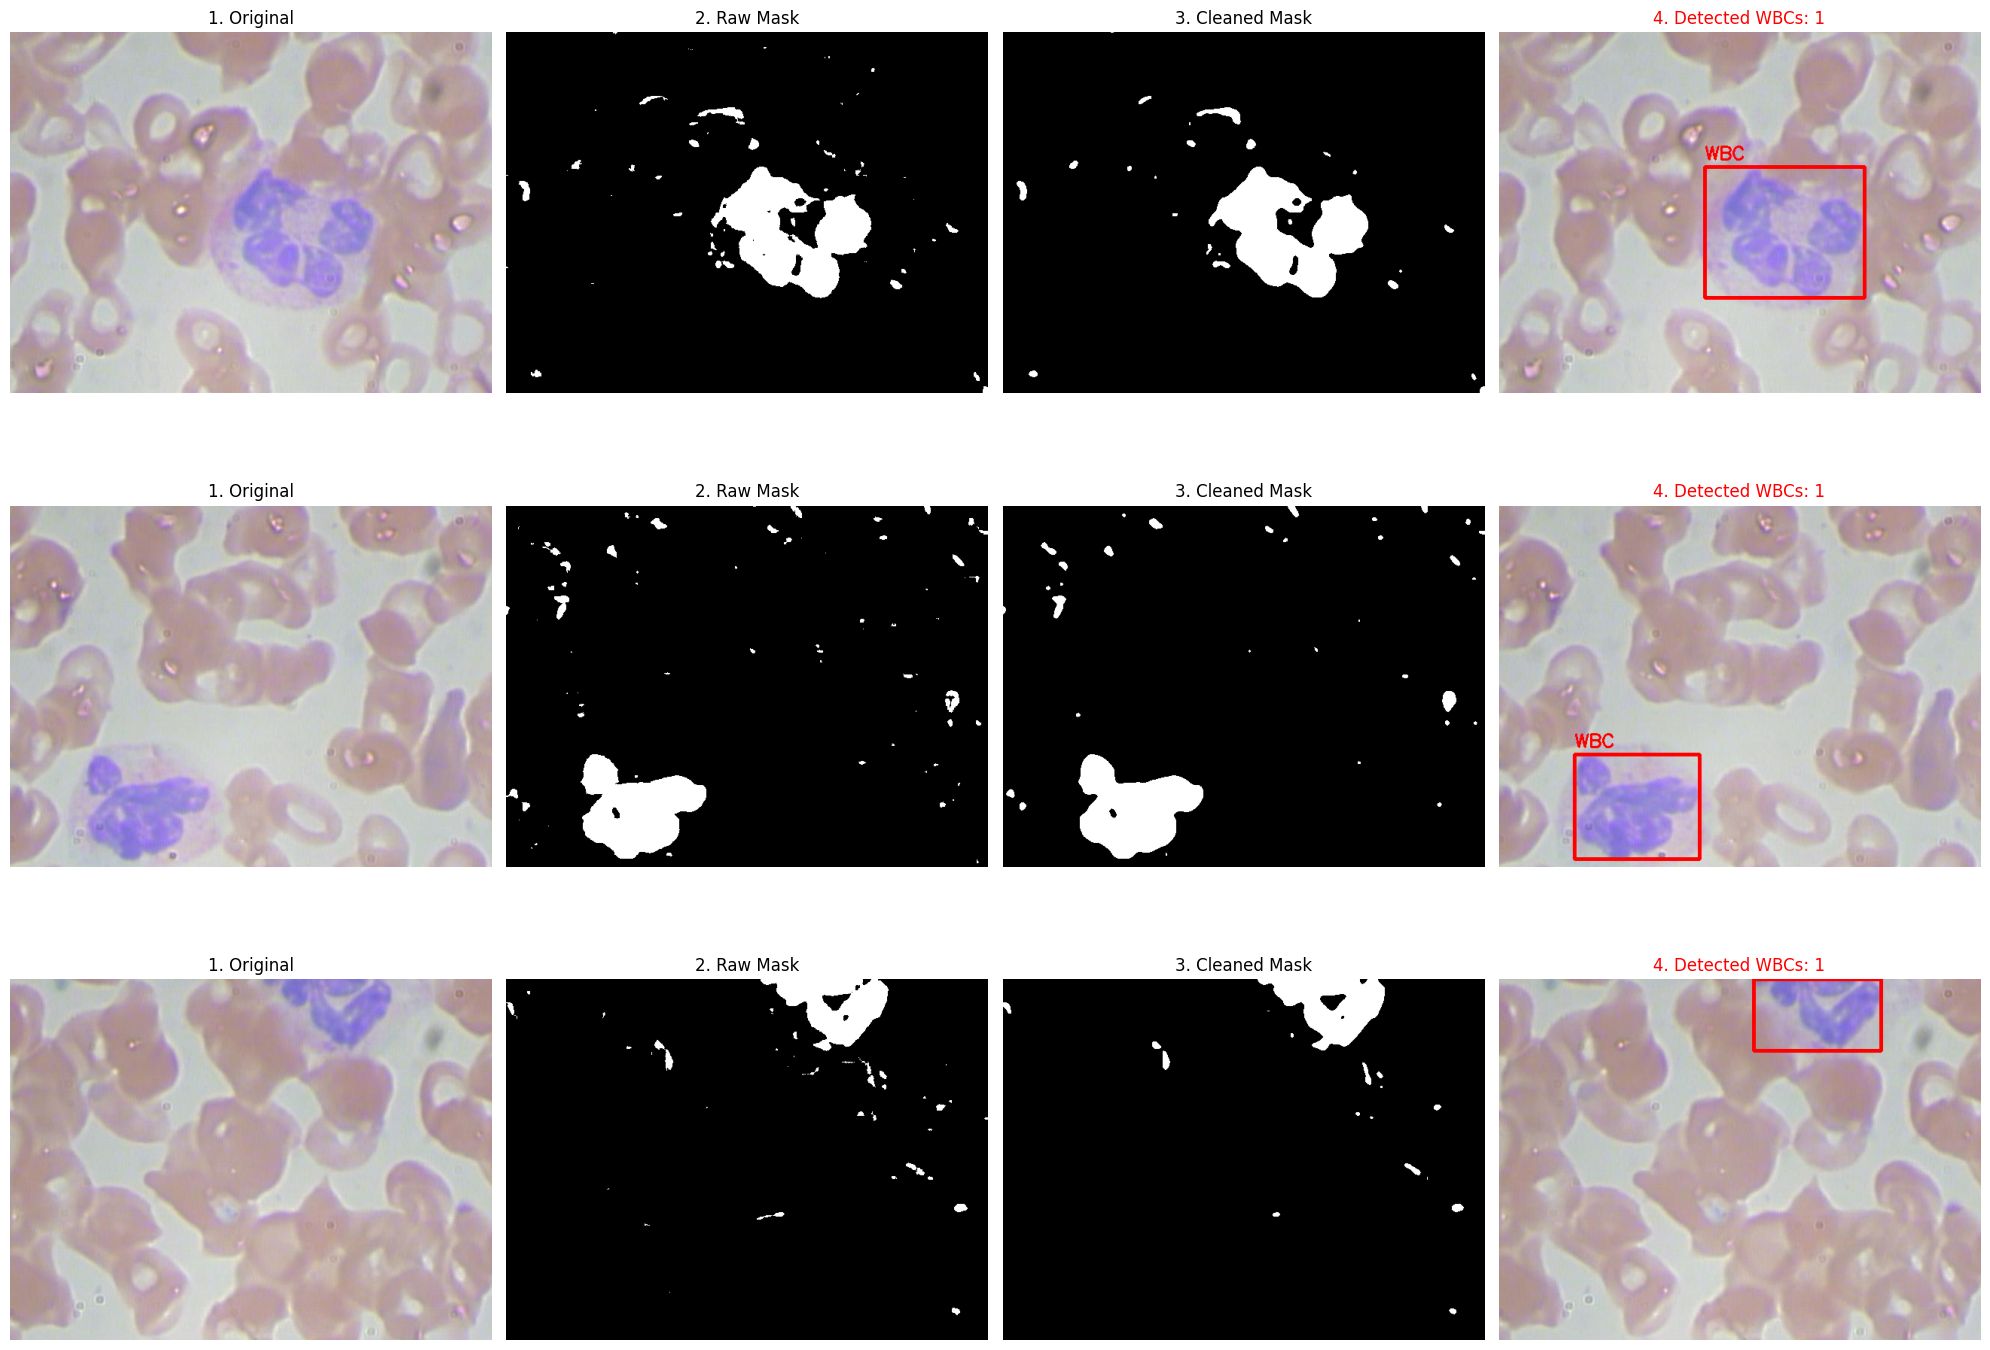

In [33]:
# ==========================================
# تجربة وتأكيد استخراج كرات الدم البيضاء (WBCs)
# ==========================================
num_samples = 3  # هنجرب على 3 صور للتأكيد
plt.figure(figsize=(20, 5 * num_samples))

for i, img_name in enumerate(test_images[:num_samples]):
    img_path = os.path.join(images_path, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 1. تشغيل دوال الـ WBCs اللي عرفناها فوق
    raw_mask = get_wbc_mask(img)
    clean_mask = clean_wbc_noise(raw_mask)
    wbc_cnts = extract_wbc_contours(clean_mask)
    result_img = draw_wbcs(img_rgb, wbc_cnts)

    # 2. عرض النتائج خطوة بخطوة
    base_idx = i * 4
    plt.subplot(num_samples, 4, base_idx + 1)
    plt.imshow(img_rgb)
    plt.title("1. Original")
    plt.axis("off")
    plt.subplot(num_samples, 4, base_idx + 2)
    plt.imshow(raw_mask, cmap="gray")
    plt.title("2. Raw Mask")
    plt.axis("off")
    plt.subplot(num_samples, 4, base_idx + 3)
    plt.imshow(clean_mask, cmap="gray")
    plt.title("3. Cleaned Mask")
    plt.axis("off")
    plt.subplot(num_samples, 4, base_idx + 4)
    plt.imshow(result_img)
    plt.title(f"4. Detected WBCs: {len(wbc_cnts)}", color="red")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
# ==========================================
# 3. دوال التجهيز المسبق لكرات الدم الحمراء (RBC Preprocessing)
# ==========================================
def enhance_rbcs(img):
    """
    تحسين الصورة لإبراز كرات الدم الحمراء بناءً على الخطوات اليدوية
    """
    # 1. استخراج القناة الخضراء (أفضل قناة لإظهار الـ RBCs غامقة)
    green_channel = img[:, :, 1]

    # 2. Contrast Stretching (لتحسين التباين)
    r_min, r_max = np.percentile(green_channel, (5, 95))
    stretched = 255.0 * (green_channel - r_min) / (r_max - r_min)
    stretched = np.clip(stretched, 0, 255).astype(np.uint8)

    # 3. Linear Smoothing (Weighted Average)
    weighted_average_kernel = (
        np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16.0
    )
    smoothed = cv2.filter2D(stretched, -1, weighted_average_kernel)

    # 4. Edge Sharpening (Composite Laplacian)
    laplacian_kernel = np.array(
        [[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]], dtype=np.float32
    )
    sharpened = cv2.filter2D(smoothed, -1, laplacian_kernel)

    # 5. Median Filter (تنظيف الشوائب النهائية باستخدام OpenCV للسرعة)
    cleaned_rbc_img = cv2.medianBlur(sharpened, 3)

    return cleaned_rbc_img

<>:4: SyntaxWarning: invalid escape sequence '\J'
<>:4: SyntaxWarning: invalid escape sequence '\J'
C:\Users\HP\AppData\Local\Temp\ipykernel_7316\2763039809.py:4: SyntaxWarning: invalid escape sequence '\J'
  test_img = cv2.imread("BCCD\JPEGImages\BloodImage_00318.jpg")


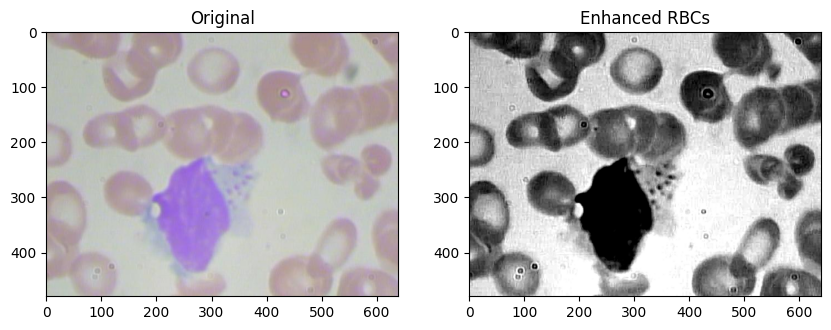

In [35]:
# تجربة دالة الـ RBCs على صورة واحدة
# test_img_path = os.path.join(images_path, test_images[0]) # أول صورة في الفولدر
# test_img = cv2.imread("BCCD\JPEGImages\BloodImage_00404.jpg")
test_img = cv2.imread("BCCD\JPEGImages\BloodImage_00318.jpg")

if test_img is not None:
    enhanced_rbc = enhance_rbcs(test_img)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.subplot(1, 2, 2)
    plt.imshow(enhanced_rbc, cmap="gray")
    plt.title("Enhanced RBCs")
    plt.show()
else:
    print("تأكد من مسار الصورة.")

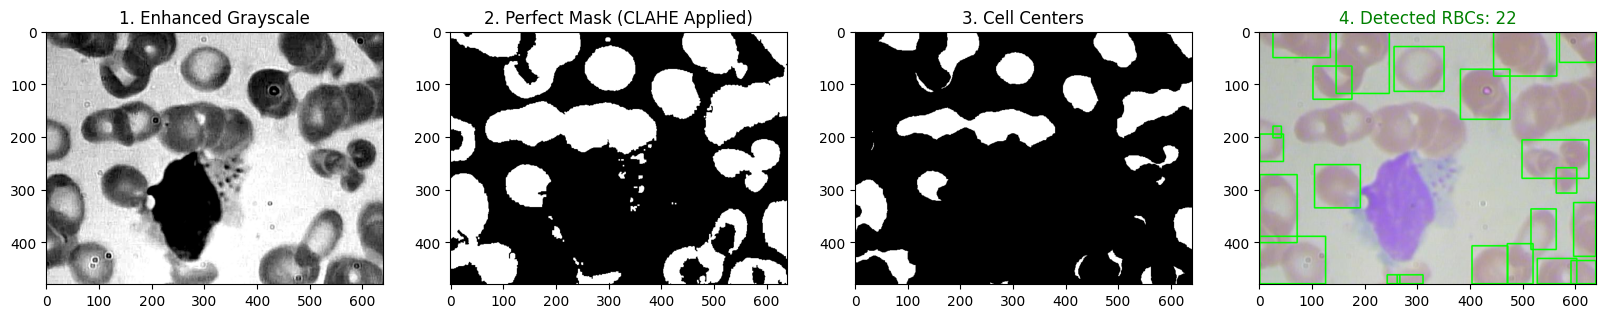

In [36]:
# ==========================================
# Cell 3: النسخة النهائية (معالجة الإضاءة بـ CLAHE + Otsu + Watershed)
# ==========================================

def get_final_rbcs(enhanced_img, wbc_mask):
    # 1. التعديل الجوهري: استخدام CLAHE لمعالجة الإضاءة الغير منتظمة وإظهار الخلايا البهتانة
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    balanced_img = clahe.apply(enhanced_img)

    # 2. دلوقتي نقدر نطبق Otsu وإحنا واثقين إنه هيشوف كل الخلايا
    _, binary = cv2.threshold(balanced_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. مسح الـ WBC بالكامل
    kernel_dilate_wbc = np.ones((15, 15), np.uint8)
    wbc_mask_dilated = cv2.dilate(wbc_mask, kernel_dilate_wbc, iterations=1)
    binary[wbc_mask_dilated == 255] = 0 
    rbc_only = binary.copy()

    # 4. سد الفجوات (Hierarchy)
    contours, hierarchy = cv2.findContours(rbc_only, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = rbc_only.copy()
    if hierarchy is not None:
        for i, cnt in enumerate(contours):
            if hierarchy[0][i][3] != -1: # لو الفراغ ده داخلي (جوه الخلية)
                cv2.drawContours(filled_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    # تنظيف خفيف
    opened_mask = cv2.morphologyEx(filled_mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=1)

    # 5. التجهيز للـ Watershed
    dist_transform = cv2.distanceTransform(opened_mask, cv2.DIST_L2, 3)
    _, sure_fg = cv2.threshold(dist_transform, 0.25 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    sure_bg = cv2.dilate(opened_mask, np.ones((3,3), np.uint8), iterations=2)
    unknown = cv2.subtract(sure_bg, sure_fg)

    # 6. ترقيم المراكز
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    # 7. فصل الخلايا (Watershed)
    img_3c = cv2.cvtColor(enhanced_img, cv2.COLOR_GRAY2BGR)
    markers = cv2.watershed(img_3c, markers)

    # 8. استخراج المربعات لكل خلية
    rbc_contours = []
    for marker_id in np.unique(markers):
        if marker_id == 1 or marker_id == -1: 
            continue
            
        cell_mask = np.zeros_like(markers, dtype=np.uint8)
        cell_mask[markers == marker_id] = 255
        
        cnts, _ = cv2.findContours(cell_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if cnts:
            cnt = max(cnts, key=cv2.contourArea)
            area = cv2.contourArea(cnt)
            if 150 < area < 8000: 
                rbc_contours.append(cnt)

    return rbc_contours, opened_mask, sure_fg

# ==========================================
# تجربة الكود ورسم المربعات 
# ==========================================
if test_img is not None:
    raw_wbc_mask = get_wbc_mask(test_img)
    clean_wbc = clean_wbc_noise(raw_wbc_mask)

    rbc_cnts, final_mask_preview, centers_preview = get_final_rbcs(enhanced_rbc, clean_wbc)

    img_test_out = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    for cnt in rbc_cnts:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_test_out, (x, y), (x + w, y + h), (0, 255, 0), 2)

    plt.figure(figsize=(20, 5))
    plt.subplot(1, 4, 1); plt.imshow(enhanced_rbc, cmap="gray"); plt.title("1. Enhanced Grayscale")
    plt.subplot(1, 4, 2); plt.imshow(final_mask_preview, cmap="gray"); plt.title("2. Perfect Mask (CLAHE Applied)")
    plt.subplot(1, 4, 3); plt.imshow(centers_preview, cmap="gray"); plt.title("3. Cell Centers")
    plt.subplot(1, 4, 4); plt.imshow(img_test_out); plt.title(f"4. Detected RBCs: {len(rbc_cnts)}", color="green")
    plt.show()

gemini

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

# ==========================================================
# النسخة المتوازنة (حل مشكلة الشوائب الصغيرة والكتل العملاقة)
# ==========================================================
def clean_and_count_watershed_balanced(rbc_mask, min_distance=12, min_area=1500, max_area=25000):
    
    # 1. إغلاق الفجوات (خليناه 9x9 عشان نلحم الخلية من غير ما نلزقها في جارتها)
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    closed_mask = cv2.morphologyEx(rbc_mask, cv2.MORPH_CLOSE, kernel_close)

    # 2. سد الخروم الداخلية 
    contours, hierarchy = cv2.findContours(closed_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    solid_mask = closed_mask.copy()
    if hierarchy is not None:
        for i in range(len(contours)):
            if hierarchy[0][i][3] != -1:
                cv2.drawContours(solid_mask, contours, i, 255, -1)

    # 3. Distance Transform & Blur 
    dist_transform = cv2.distanceTransform(solid_mask, cv2.DIST_L2, 5)
    # قللنا البلور لـ 9x9 عشان القمم تفضل مفصولة
    dist_blurred = cv2.GaussianBlur(dist_transform, (9, 9), 0)

    # 4. إيجاد المراكز (ظبطنا الأرقام للنص عشان نفصل الخلايا الملتصقة)
    local_max_coords = peak_local_max(
        dist_blurred, 
        min_distance=min_distance, 
        threshold_abs=0.8, 
        labels=solid_mask
    )

    markers = np.zeros(solid_mask.shape, dtype=np.int32)
    for i, coord in enumerate(local_max_coords):
        markers[coord[0], coord[1]] = i + 1

    # 5. فصل الخلايا (Watershed)
    labels = watershed(-dist_blurred, markers, mask=solid_mask)

    # 6. استخراج المربعات 
    bboxes = []
    for label_id in np.unique(labels):
        if label_id == 0: 
            continue
        
        cell_mask = np.uint8(labels == label_id) * 255
        cnts, _ = cv2.findContours(cell_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if cnts:
            cnt = max(cnts, key=cv2.contourArea)
            area = cv2.contourArea(cnt)
            
            # السر هنا: 1500 هتموت كل الشوائب اللي تحت، و25000 هتقبل الخلايا السليمة
            if min_area < area < max_area:
                x, y, w, h = cv2.boundingRect(cnt)
                bboxes.append((x, y, w, h))
                    
    return labels, bboxes, solid_mask

# ==========================================
# كود التشغيل
# ==========================================
if 'test_img' in locals() and test_img is not None:
    raw_wbc_mask = get_wbc_mask(test_img)
    clean_wbc = clean_wbc_noise(raw_wbc_mask)
    
    rbc_mask = get_final_rbcs(enhanced_rbc, clean_wbc)
    
    # نستخدم الدالة المتوازنة
    labels, bboxes, solid_mask = clean_and_count_watershed_balanced(rbc_mask)
    
    img_out = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    for (x, y, w, h) in bboxes:
        cv2.rectangle(img_out, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cx, cy = x + w//2, y + h//2
        cv2.circle(img_out, (cx, cy), 4, (255, 0, 0), -1)
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(enhanced_rbc, cmap="gray")
    axes[0].set_title("1. Enhanced")
    
    axes[1].imshow(solid_mask, cmap="gray")
    axes[1].set_title("2. Solid Mask (Balanced)")
    
    axes[2].imshow(labels, cmap="nipy_spectral")
    axes[2].set_title("3. Watershed Labels")
    
    axes[3].imshow(img_out)
    axes[3].set_title(f"4. Detected RBCs: {len(bboxes)}", color="green")
    
    plt.tight_layout()
    plt.show()

error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'morphologyEx'
> Overload resolution failed:
>  - src is not a numerical tuple
>  - Expected Ptr<cv::UMat> for argument 'src'


claude

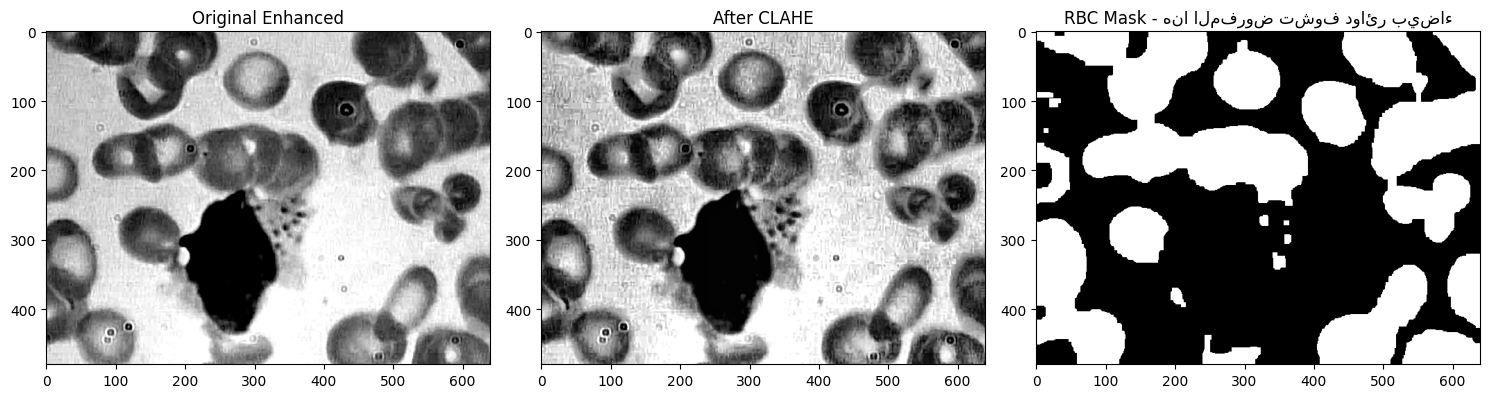

✅ قبلنا: 23 | ❌ رفضنا: 4
   Label 6: 11388px - سبب: area
   Label 10: 2728px - سبب: shape ar=0.40 circ=0.93 comp=0.65
   Label 13: 4953px - سبب: shape ar=2.68 circ=0.74 comp=0.49
   Label 15: 1946px - سبب: shape ar=0.28 circ=0.86 comp=0.50


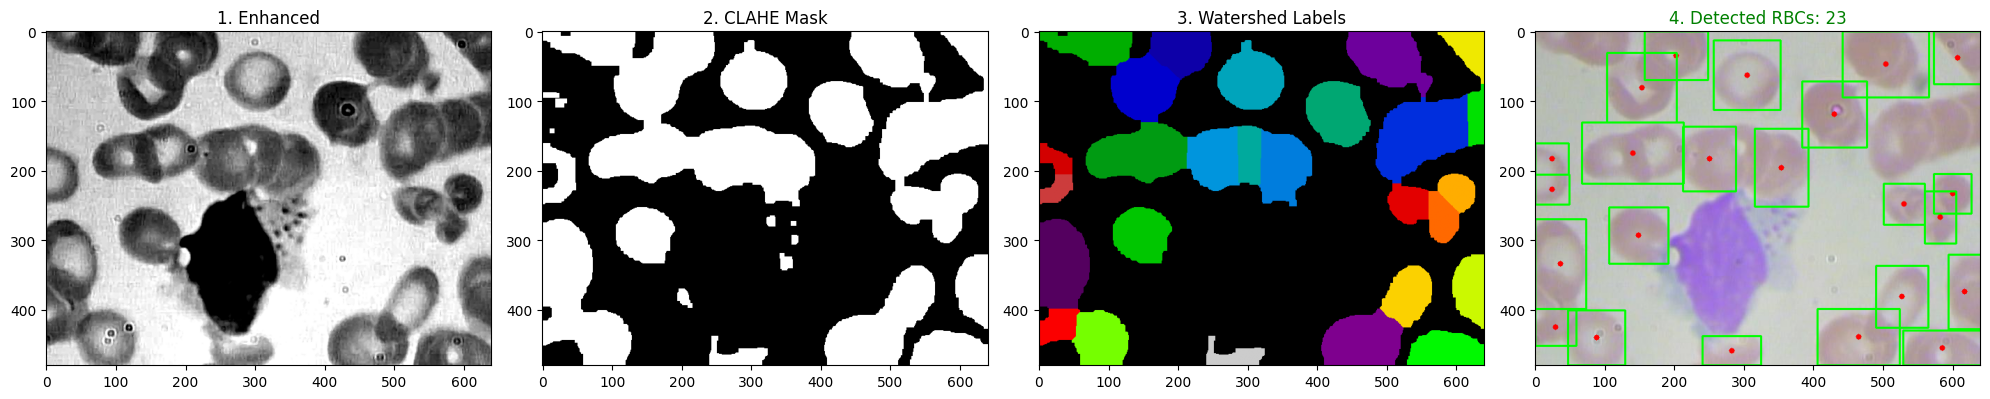

In [ ]:
def get_rbc_mask_v5(enhanced_img, wbc_mask):
    """
    Otsu محسّن مع CLAHE قبله
    """
    # CLAHE: يحسن التباين محلياً قبل الـ threshold
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(enhanced_img)
    
    # Otsu بس على الـ CLAHE image
    _, binary_mask = cv2.threshold(
        clahe_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    
    # إزالة WBCs
    kernel_dilate = np.ones((7, 7), np.uint8)
    wbc_mask_dilated = cv2.dilate(wbc_mask, kernel_dilate, iterations=2)
    wbc_mask_inv = cv2.bitwise_not(wbc_mask_dilated)
    rbc_only = cv2.bitwise_and(binary_mask, wbc_mask_inv)
    
    # Closing
    kernel_close = np.ones((5, 5), np.uint8)
    rbc_closed = cv2.morphologyEx(rbc_only, cv2.MORPH_CLOSE, kernel_close, iterations=3)
    
    # Fill rings
    rbc_filled = fill_rbc_rings(rbc_closed)
    
    # Opening
    kernel_open = np.ones((7, 7), np.uint8)
    rbc_clean = cv2.morphologyEx(rbc_filled, cv2.MORPH_OPEN, kernel_open, iterations=1)
    
    return rbc_clean, clahe_img  # نرجع الـ clahe عشان نشوفه


# ==========================================
# تشغيل مع debug للـ mask
# ==========================================
if test_img is not None:
    raw_wbc_mask = get_wbc_mask(test_img)
    clean_wbc = clean_wbc_noise(raw_wbc_mask)
    
    rbc_mask, clahe_img = get_rbc_mask_v5(enhanced_rbc, clean_wbc)
    
    # ← أول حاجة: نشوف الـ mask صح ولا لا
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(enhanced_rbc, cmap="gray")
    axes[0].set_title("Original Enhanced")
    axes[1].imshow(clahe_img, cmap="gray")
    axes[1].set_title("After CLAHE")
    axes[2].imshow(rbc_mask, cmap="gray")
    axes[2].set_title("RBC Mask - هنا المفروض تشوف دوائر بيضاء")
    plt.tight_layout()
    plt.show()
    
    # لو الـ mask صح → نكمل العد
    labels, bboxes = count_rbcs_final(rbc_mask)
    
    img_out = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    for (x, y, w, h) in bboxes:
        cv2.rectangle(img_out, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cx, cy = x + w//2, y + h//2
        cv2.circle(img_out, (cx, cy), 4, (255, 0, 0), -1)
    
    fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))
    axes2[0].imshow(enhanced_rbc, cmap="gray")
    axes2[0].set_title("1. Enhanced")
    axes2[1].imshow(rbc_mask, cmap="gray")
    axes2[1].set_title("2. CLAHE Mask")
    axes2[2].imshow(labels, cmap="nipy_spectral")
    axes2[2].set_title("3. Watershed Labels")
    axes2[3].imshow(img_out)
    axes2[3].set_title(f"4. Detected RBCs: {len(bboxes)}", color="green")
    plt.tight_layout()
    plt.show()

NameError: name 'count_rbcs_final' is not defined

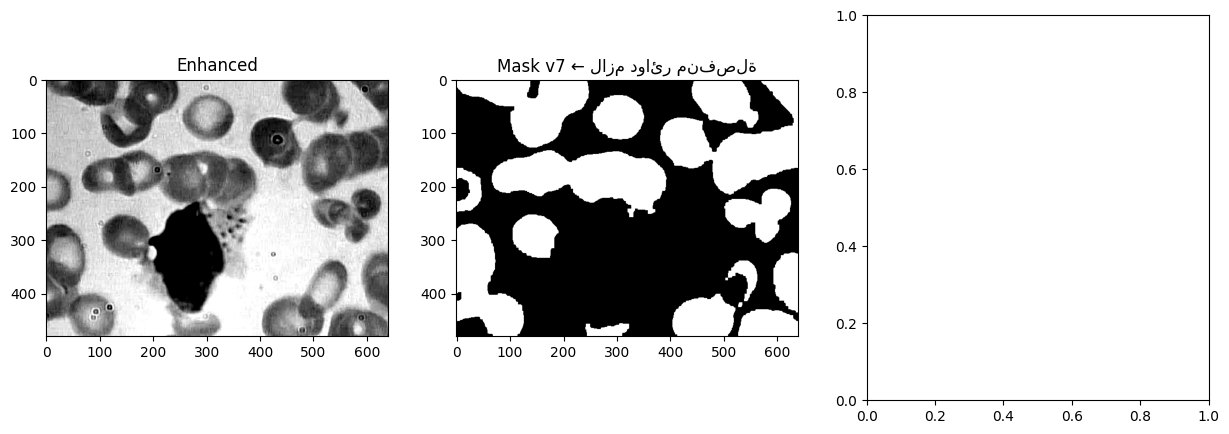

In [ ]:
def get_rbc_mask_v7(enhanced_img, wbc_mask):
    """
    نعالج كل خلية لوحدها بدل ما نعمل closing على الصورة كلها
    """
    # Threshold = 150
    _, binary_mask = cv2.threshold(enhanced_img, 150, 255, cv2.THRESH_BINARY_INV)
    
    # إزالة WBCs
    kernel_dilate = np.ones((7, 7), np.uint8)
    wbc_dilated = cv2.dilate(wbc_mask, kernel_dilate, iterations=2)
    rbc_only = cv2.bitwise_and(binary_mask, cv2.bitwise_not(wbc_dilated))
    
    # Closing صغير بس عشان مايوصلش الخلايا
    kernel_close = np.ones((3, 3), np.uint8)
    rbc_closed = cv2.morphologyEx(rbc_only, cv2.MORPH_CLOSE, kernel_close, iterations=2)
    
    # نلاقي كل contour منفرد
    contours, _ = cv2.findContours(
        rbc_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    
    filled_mask = np.zeros_like(rbc_closed)
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        
        # نتجاهل الضوضاء الصغيرة جداً
        if area < 200:
            continue
        
        # نرسم الخلية دي لوحدها في mask مؤقت
        temp = np.zeros_like(rbc_closed)
        cv2.drawContours(temp, [cnt], -1, 255, thickness=cv2.FILLED)
        
        # Flood fill على الخلية دي بس
        h, w = temp.shape
        padded = np.zeros((h+2, w+2), np.uint8)
        padded[1:h+1, 1:w+1] = temp
        
        # نملأ من corner
        flood = padded.copy()
        cv2.floodFill(flood, None, (0, 0), 255)
        flood_inv = cv2.bitwise_not(flood)[1:h+1, 1:w+1]
        
        # نضيف الخلية المملوءة للـ mask النهائي
        filled_mask = cv2.bitwise_or(filled_mask, temp | flood_inv)
    
    # Opening خفيف لإزالة الضوضاء
    kernel_open = np.ones((5, 5), np.uint8)
    rbc_clean = cv2.morphologyEx(filled_mask, cv2.MORPH_OPEN, kernel_open, iterations=1)
    
    return rbc_clean


# ==========================================
# تشغيل
# ==========================================

if test_img is not None:
    raw_wbc_mask = get_wbc_mask(test_img)
    clean_wbc = clean_wbc_noise(raw_wbc_mask)
    
    rbc_mask = get_rbc_mask_v7(enhanced_rbc, clean_wbc)
    
    # Debug: نشوف الـ mask
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(enhanced_rbc, cmap="gray")
    axes[0].set_title("Enhanced")
    axes[1].imshow(rbc_mask, cmap="gray")
    axes[1].set_title("Mask v7 ← لازم دوائر منفصلة")
    
    labels, bboxes = count_rbcs_final(rbc_mask)
    
    img_out = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    for (x, y, w, h) in bboxes:
        cv2.rectangle(img_out, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.circle(img_out, (x+w//2, y+h//2), 4, (255, 0, 0), -1)
    
    axes[2].imshow(img_out)
    axes[2].set_title(f"Detected RBCs: {len(bboxes)}", color="green")
    plt.tight_layout()
    plt.show()
    
    print(f"✅ عدد الـ RBCs: {len(bboxes)}")

In [ ]:
plt.imshow(img_out)
plt.axis(False)

NameError: name 'plt' is not defined